# Đồ án 5: Linear Regression — Đánh giá chất lượng rượu

**Môn:** Toán ứng dụng và thống kê cho Công nghệ thông tin

**Sinh viên:** Nguyễn Thế Hiển

**MSSV:** 22127107

**Lớp:** 24C05

## 1. Mở đầu

Hồi quy tuyến tính là một trong những mô hình thống kê nền tảng nhất để mô tả quan hệ giữa biến phụ thuộc và các biến giải thích. Trong đồ án này, ta xây dựng mô hình đánh giá chất lượng rượu (`quality`) từ các chỉ số hóa lý trong tập dữ liệu `wine.csv` bằng thuật toán **Ordinary Least Squares (OLS)**.

Mục tiêu không chỉ là thu được một mô hình dự đoán tốt, mà còn là làm rõ cơ chế toán học của OLS, kiểm chứng bằng **cross-validation**, và thiết kế một biến thể mô hình tự chọn sao cho hiệu năng tổng quát hóa được cải thiện một cách có kiểm soát.

## 2. Mục tiêu và phạm vi thực hiện

Theo đề bài, đồ án thực hiện ba yêu cầu:

- **(a)** Xây dựng mô hình OLS dùng **toàn bộ 11 đặc trưng** có sẵn.
- **(b)** Xây dựng mô hình OLS chỉ với **một đặc trưng cho kết quả tốt nhất**, dùng **Cross Validation** để lựa chọn.
- **(c)** Thiết kế mô hình tùy biến nhằm đạt kết quả tốt nhất có thể trong khuôn khổ OLS.

Phạm vi kỹ thuật:

- Tự cài đặt OLS theo phương trình chuẩn (normal equations).
- **Không** dùng các hàm hồi quy có sẵn như `sklearn.linear_model.LinearRegression` hay `statsmodels.OLS` để ước lượng hệ số.
- NumPy chỉ được dùng cho đại số tuyến tính cơ bản (nhân ma trận, giải hệ); pandas/matplotlib hỗ trợ đọc dữ liệu và trực quan hóa.

## 3. Quy ước ký hiệu

| Ký hiệu | Ý nghĩa |
|---|---|
| $n$ | Số mẫu quan sát |
| $p$ | Số đặc trưng (không kể hệ số chặn) |
| $\mathbf{y}\in\mathbb{R}^n$ | Vector chất lượng rượu (biến phụ thuộc) |
| $X\in\mathbb{R}^{n\times (p+1)}$ | Ma trận thiết kế, cột đầu là $1$ (intercept) |
| $\boldsymbol{\beta}\in\mathbb{R}^{p+1}$ | Vector hệ số hồi quy |
| $\hat{\boldsymbol{\beta}}$ | Ước lượng OLS của $\boldsymbol{\beta}$ |
| $\hat{\mathbf{y}}=X\hat{\boldsymbol{\beta}}$ | Vector giá trị dự đoán |
| $\mathbf{e}=\mathbf{y}-\hat{\mathbf{y}}$ | Vector phần dư |
| $\mathrm{MSE},\mathrm{RMSE},\mathrm{MAE},R^2$ | Các chỉ số đánh giá mô hình |

## 4. Cấu trúc nội dung

1. Trình bày lý thuyết OLS và các chỉ số đánh giá.
2. Cài đặt các hàm cần thiết (OLS, metrics, $k$-fold CV, chuẩn hóa).
3. Khám phá dữ liệu `wine.csv`.
4. Thực nghiệm phần (a), (b), (c).
5. So sánh mô hình, nhận xét và kết luận.
6. Mô tả ý tưởng thực hiện và các hàm đã viết.


## 5. Lý thuyết Ordinary Least Squares (OLS)

### 5.1. Mô hình tuyến tính

Xét mô hình

$$
y_i = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip} + \varepsilon_i,
\qquad i=1,\dots,n,
$$

hay dạng ma trận

$$
\mathbf{y}=X\boldsymbol{\beta}+\boldsymbol{\varepsilon}.
$$

Cột đầu của $X$ là vector toàn số $1$ để ước lượng hệ số chặn $\beta_0$.

### 5.2. Tiêu chí bình phương tối thiểu

OLS chọn $\hat{\boldsymbol{\beta}}$ sao cho tổng bình phương phần dư nhỏ nhất:

$$
S(\boldsymbol{\beta})=\lVert \mathbf{y}-X\boldsymbol{\beta}\rVert_2^2
=\sum_{i=1}^{n}\bigl(y_i-\mathbf{x}_i^\top\boldsymbol{\beta}\bigr)^2.
$$

Lấy đạo hàm theo $\boldsymbol{\beta}$ và cho bằng $\mathbf{0}$ ta được **phương trình chuẩn**:

$$
X^\top X\,\hat{\boldsymbol{\beta}}=X^\top\mathbf{y}.
$$

Nếu $X^\top X$ khả nghịch thì nghiệm đóng là

$$
\hat{\boldsymbol{\beta}}=(X^\top X)^{-1}X^\top\mathbf{y}.
$$

Trong cài đặt, thay vì nhân ngược ma trận tường minh, ta giải hệ $(X^\top X)\boldsymbol{\beta}=X^\top\mathbf{y}$ bằng `numpy.linalg.solve` — tương đương công thức trên nhưng ổn định số hơn.

### 5.3. Chỉ số đánh giá

- $\displaystyle\mathrm{MSE}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2$
- $\displaystyle\mathrm{RMSE}=\sqrt{\mathrm{MSE}}$
- $\displaystyle\mathrm{MAE}=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|$
- $\displaystyle R^2=1-\frac{\sum_i(y_i-\hat{y}_i)^2}{\sum_i(y_i-\bar{y})^2}$

$R^2$ đo tỷ lệ phương sai của $\mathbf{y}$ được mô hình giải thích. Trên dữ liệu huấn luyện, thêm biến luôn không làm giảm $R^2$; vì vậy khi so sánh mô hình ta ưu tiên **MSE/$R^2$ trên tập kiểm tra của cross-validation**.

### 5.4. $k$-fold Cross Validation

Chia $n$ mẫu thành $k$ fold gần bằng nhau. Với mỗi fold $i$:

1. Huấn luyện OLS trên $k-1$ fold còn lại.
2. Đánh giá trên fold $i$.

Điểm CV là trung bình các fold. Quy trình này giảm thiên lệch của việc đánh giá trên cùng tập huấn luyện và là tiêu chí chính để chọn đặc trưng ở phần (b) và (c).


## 6. Cài đặt thuật toán và tiện ích

Các hàm chính:

- `add_intercept`: thêm cột $1$ vào ma trận đặc trưng.
- `ols_fit` / `ols_predict`: ước lượng và dự đoán OLS.
- `mse`, `rmse`, `mae`, `r2_score`: chỉ số đánh giá.
- `train_test_metrics`: gói các chỉ số thành dictionary.
- `kfold_split`: tạo chỉ số $k$-fold có xáo trộn cố định.
- `cross_validate_ols`: đánh giá OLS bằng $k$-fold CV.
- `standardize_fit_transform` / `standardize_transform`: chuẩn hóa theo thống kê tập train (tránh rò rỉ thông tin).
- `pearson_corr`: hệ số tương quan Pearson (dùng cho EDA).


In [81]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Một số bản NumPy/BLAS phát RuntimeWarning giả trên phép @ dù kết quả vẫn hữu hạn.
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    message=r".*encountered in matmul.*",
)

np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
RANDOM_SEED = 42
K_FOLDS = 5

plt.rcParams.update({
    'figure.figsize': (8, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
})


In [82]:
def add_intercept(X):
    """Thêm cột intercept (=1) vào bên trái ma trận đặc trưng."""
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return np.column_stack([np.ones(X.shape[0]), X])


def ols_fit(X, y):
    """
    Ước lượng OLS bằng phương trình chuẩn:
        (X^T X) beta = X^T y
    tương đương beta = (X^T X)^{-1} X^T y.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    XtX = X.T @ X
    Xty = X.T @ y
    beta = np.linalg.solve(XtX, Xty)
    return beta


def ols_predict(X, beta):
    """Dự đoán y_hat = X beta."""
    return np.asarray(X, dtype=float) @ np.asarray(beta, dtype=float)


def mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    return float(np.mean((y_true - y_pred) ** 2))


def rmse(y_true, y_pred):
    return float(np.sqrt(mse(y_true, y_pred)))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    return float(np.mean(np.abs(y_true - y_pred)))


def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 0.0
    return float(1.0 - ss_res / ss_tot)


def train_test_metrics(y_true, y_pred):
    return {
        'MSE': mse(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAE': mae(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }


def kfold_split(n_samples, n_splits=K_FOLDS, seed=RANDOM_SEED):
    """Trả về list các mảng chỉ số cho từng fold (đã xáo trộn)."""
    rng = np.random.default_rng(seed)
    indices = rng.permutation(n_samples)
    return [np.asarray(fold, dtype=int) for fold in np.array_split(indices, n_splits)]


def standardize_fit_transform(X_train):
    """Chuẩn hóa z-score trên tập train; trả về (X_scaled, mean, std)."""
    X_train = np.asarray(X_train, dtype=float)
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std = np.where(std == 0, 1.0, std)
    return (X_train - mean) / std, mean, std


def standardize_transform(X, mean, std):
    return (np.asarray(X, dtype=float) - mean) / std


def pearson_corr(x, y):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    x_c = x - x.mean()
    y_c = y - y.mean()
    denom = np.linalg.norm(x_c) * np.linalg.norm(y_c)
    if denom == 0:
        return 0.0
    return float((x_c @ y_c) / denom)


def cross_validate_ols(X, y, n_splits=K_FOLDS, seed=RANDOM_SEED, standardize=False):
    """
    k-fold CV cho OLS.
    Nếu standardize=True, mean/std được ước lượng CHỈ trên fold train.
    """
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    y = np.asarray(y, dtype=float).reshape(-1)

    folds = kfold_split(len(y), n_splits=n_splits, seed=seed)
    rows = []

    for i in range(n_splits):
        test_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(n_splits) if j != i])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if standardize:
            X_train, mean, std = standardize_fit_transform(X_train)
            X_test = standardize_transform(X_test, mean, std)

        beta = ols_fit(add_intercept(X_train), y_train)
        y_hat = ols_predict(add_intercept(X_test), beta)
        m = train_test_metrics(y_test, y_hat)
        m['fold'] = i + 1
        rows.append(m)

    cv_df = pd.DataFrame(rows)
    summary = {
        'CV_MSE': cv_df['MSE'].mean(),
        'CV_RMSE': cv_df['RMSE'].mean(),
        'CV_MAE': cv_df['MAE'].mean(),
        'CV_R2': cv_df['R2'].mean(),
        'CV_MSE_std': cv_df['MSE'].std(ddof=0),
        'CV_R2_std': cv_df['R2'].std(ddof=0),
    }
    return cv_df, summary


## 7. Dữ liệu và khám phá ban đầu

Tập `wine.csv` gồm khoảng $1200$ mẫu rượu, mỗi mẫu có điểm `quality` (thang khoảng $1$–$10$) cùng $11$ chỉ số hóa lý. Trước khi hồi quy, ta kiểm tra kích thước, phân phối biến đích và tương quan tuyến tính của từng đặc trưng với `quality`.


In [83]:
df = pd.read_csv('wine.csv')
df.columns = [c.strip().strip('"') for c in df.columns]

print('Kích thước dữ liệu:', df.shape)
print('Các cột:', list(df.columns))
print('\nKiểu dữ liệu:')
print(df.dtypes)
print('\nSố giá trị thiếu theo cột:')
print(df.isnull().sum())
df.head()


Kích thước dữ liệu: (1199, 12)
Các cột: ['quality', 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Kiểu dữ liệu:
quality                   int64
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide      int64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
dtype: object

Số giá trị thiếu theo cột:
quality                 0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64


,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,5,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34,0.997800,3.510000,0.560000,9.400000
1,5,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67,0.996800,3.200000,0.680000,9.800000
2,5,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54,0.997000,3.260000,0.650000,9.800000
3,6,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60,0.998000,3.160000,0.580000,9.800000
4,5,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34,0.997800,3.510000,0.560000,9.400000


In [84]:
TARGET = 'quality'
FEATURES = [c for c in df.columns if c != TARGET]

y = df[TARGET].to_numpy(dtype=float)
X_all = df[FEATURES].to_numpy(dtype=float)

print('Số đặc trưng:', len(FEATURES))
print('Phân phối quality:')
print(df[TARGET].value_counts().sort_index())
df.describe().T


Số đặc trưng: 11
Phân phối quality:
quality
3      5
4     35
5    513
6    463
7    170
8     13
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
quality,1199.000000,5.664721,0.809593,3.000000,5.000000,6.000000,6.000000,8.000000
fixed acidity,1199.000000,8.625271,1.781795,4.600000,7.300000,8.300000,9.600000,15.900000
volatile acidity,1199.000000,0.519133,0.179208,0.120000,0.390000,0.500000,0.630000,1.330000
citric acid,1199.000000,0.293353,0.196751,0.000000,0.120000,0.290000,0.450000,1.000000
residual sugar,1199.000000,2.564470,1.264441,0.900000,1.900000,2.200000,2.700000,15.500000
chlorides,1199.000000,0.089266,0.048310,0.012000,0.071000,0.080000,0.092000,0.611000
free sulfur dioxide,1199.000000,15.242702,10.210406,1.000000,7.000000,13.000000,21.000000,68.000000
total sulfur dioxide,1199.000000,46.884070,33.949177,6.000000,21.000000,38.000000,63.000000,289.000000
density,1199.000000,0.997059,0.001878,0.990070,0.996000,0.997020,0.998175,1.003200
pH,1199.000000,3.298582,0.156161,2.740000,3.195000,3.300000,3.390000,3.900000


In [85]:
corr_rows = []
for j, name in enumerate(FEATURES):
    r = pearson_corr(X_all[:, j], y)
    corr_rows.append({'feature': name, 'corr_with_quality': r, 'abs_corr': abs(r)})

corr_df = pd.DataFrame(corr_rows).sort_values('abs_corr', ascending=False).reset_index(drop=True)
corr_df


,feature,corr_with_quality,abs_corr
0,alcohol,0.505369,0.505369
1,volatile acidity,-0.379885,0.379885
2,citric acid,0.228205,0.228205
3,total sulfur dioxide,-0.226884,0.226884
4,sulphates,0.211381,0.211381
5,density,-0.192464,0.192464
6,fixed acidity,0.149037,0.149037
7,chlorides,-0.124468,0.124468
8,pH,-0.075664,0.075664
9,free sulfur dioxide,-0.074971,0.074971


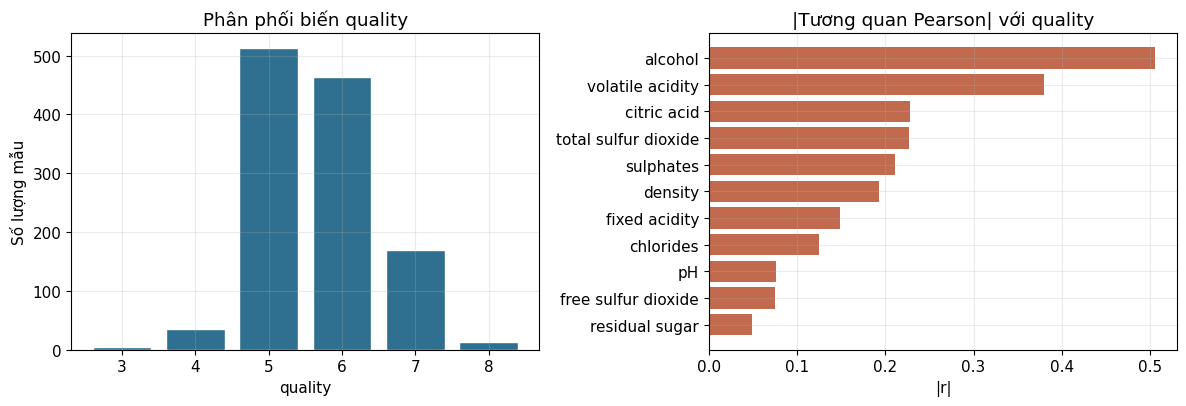

Nhận xét nhanh:
- quality tập trung chủ yếu ở mức 5–6; miền giá trị quan sát: 3–8.
- Đặc trưng tương quan mạnh nhất: alcohol (r = +0.5054).
- Không có giá trị thiếu; toàn bộ biến đều số học nên phù hợp trực tiếp với OLS.


In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Phân phối quality
qc = df[TARGET].value_counts().sort_index()
axes[0].bar(qc.index.astype(str), qc.values, color='#2f6f8f', edgecolor='white')
axes[0].set_title('Phân phối biến quality')
axes[0].set_xlabel('quality')
axes[0].set_ylabel('Số lượng mẫu')

# |corr| với quality
axes[1].barh(corr_df['feature'][::-1], corr_df['abs_corr'][::-1], color='#c16a4e')
axes[1].set_title('|Tương quan Pearson| với quality')
axes[1].set_xlabel('|r|')

plt.tight_layout()
plt.show()

print('Nhận xét nhanh:')
print(f"- quality tập trung chủ yếu ở mức 5–6; miền giá trị quan sát: {int(y.min())}–{int(y.max())}.")
print(f"- Đặc trưng tương quan mạnh nhất: {corr_df.loc[0, 'feature']} (r = {corr_df.loc[0, 'corr_with_quality']:+.4f}).")
print('- Không có giá trị thiếu; toàn bộ biến đều số học nên phù hợp trực tiếp với OLS.')


## 8. Phần (a) — Mô hình OLS với toàn bộ 11 đặc trưng

Ta ước lượng

$$
\hat{q}
=
\hat\beta_0
+
\sum_{j=1}^{11}\hat\beta_j\,x_j
$$

trên toàn bộ dữ liệu, đồng thời đánh giá độ tổng quát hóa bằng 5-fold CV để có cơ sở so sánh với (b) và (c).


In [87]:
# Huấn luyện trên toàn bộ dữ liệu
X_a = add_intercept(X_all)
beta_a = ols_fit(X_a, y)
y_hat_a = ols_predict(X_a, beta_a)
metrics_a_full = train_test_metrics(y, y_hat_a)

coef_a = pd.DataFrame({
    'term': ['intercept'] + FEATURES,
    'coefficient': beta_a,
})
print('=== Hệ số mô hình (a) ===')
display(coef_a)

print('=== Đánh giá trên toàn bộ dữ liệu (in-sample) ===')
for k, v in metrics_a_full.items():
    print(f'{k:>5}: {v:.6f}')

cv_a_df, cv_a = cross_validate_ols(X_all, y, standardize=False)
print('\n=== 5-fold Cross Validation — mô hình (a) ===')
display(cv_a_df)
print('Trung bình CV:')
for k, v in cv_a.items():
    print(f'{k}: {v:.6f}')


=== Hệ số mô hình (a) ===


,term,coefficient
0,intercept,42.917162
1,fixed acidity,0.047525
2,volatile acidity,-1.068743
3,citric acid,-0.268711
4,residual sugar,0.034974
5,chlorides,-1.597296
6,free sulfur dioxide,0.003488
7,total sulfur dioxide,-0.003798
8,density,-39.469081
9,pH,-0.245576


=== Đánh giá trên toàn bộ dữ liệu (in-sample) ===
  MSE: 0.407153
 RMSE: 0.638085
  MAE: 0.499790
   R2: 0.378291

=== 5-fold Cross Validation — mô hình (a) ===


,MSE,RMSE,MAE,R2,fold
0,0.348969,0.590736,0.475258,0.398905,1
1,0.456762,0.675842,0.519613,0.320782,2
2,0.447851,0.669216,0.522182,0.324778,3
3,0.450279,0.671028,0.526425,0.401167,4
4,0.379077,0.615692,0.481705,0.359712,5


Trung bình CV:
CV_MSE: 0.416588
CV_RMSE: 0.644503
CV_MAE: 0.505037
CV_R2: 0.361069
CV_MSE_std: 0.044058
CV_R2_std: 0.034587


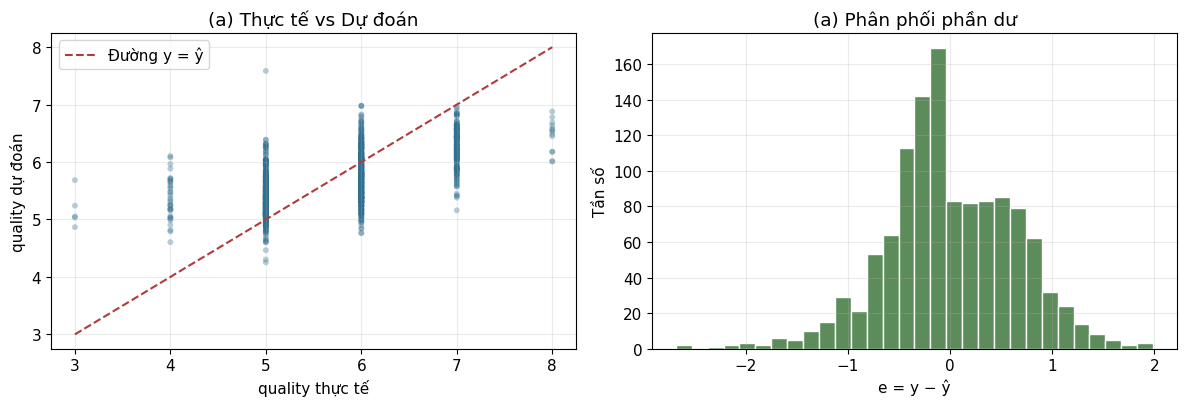

In-sample R^2 (a) = 0.3783 | CV R^2 (a) = 0.3611


In [88]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].scatter(y, y_hat_a, alpha=0.35, s=18, color='#2f6f8f', edgecolors='none')
lims = [min(y.min(), y_hat_a.min()), max(y.max(), y_hat_a.max())]
axes[0].plot(lims, lims, '--', color='#b33a3a', linewidth=1.5, label='Đường y = ŷ')
axes[0].set_xlabel('quality thực tế')
axes[0].set_ylabel('quality dự đoán')
axes[0].set_title('(a) Thực tế vs Dự đoán')
axes[0].legend()

resid_a = y - y_hat_a
axes[1].hist(resid_a, bins=30, color='#5b8c5a', edgecolor='white')
axes[1].set_title('(a) Phân phối phần dư')
axes[1].set_xlabel('e = y − ŷ')
axes[1].set_ylabel('Tần số')

plt.tight_layout()
plt.show()

print(f"In-sample R^2 (a) = {metrics_a_full['R2']:.4f} | CV R^2 (a) = {cv_a['CV_R2']:.4f}")


## 9. Phần (b) — Một đặc trưng tốt nhất (có Cross Validation)

Với mỗi đặc trưng $x_j$, ta xây dựng mô hình đơn biến

$$
\hat{q}=\hat\beta_0+\hat\beta_1 x_j
$$

và chọn $x_j$ có **CV-MSE nhỏ nhất** (tương đương CV-$R^2$ lớn nhất trong thực nghiệm này). Đây đúng gợi ý của đề: dùng Cross Validation thay vì chỉ nhìn $R^2$ in-sample.


In [89]:
single_rows = []
for j, name in enumerate(FEATURES):
    _, summary = cross_validate_ols(X_all[:, [j]], y, standardize=False)
    # Đồng thời ghi nhận fit toàn tập để tham khảo
    beta_tmp = ols_fit(add_intercept(X_all[:, [j]]), y)
    y_tmp = ols_predict(add_intercept(X_all[:, [j]]), beta_tmp)
    full_m = train_test_metrics(y, y_tmp)
    single_rows.append({
        'feature': name,
        'CV_MSE': summary['CV_MSE'],
        'CV_RMSE': summary['CV_RMSE'],
        'CV_MAE': summary['CV_MAE'],
        'CV_R2': summary['CV_R2'],
        'Full_MSE': full_m['MSE'],
        'Full_R2': full_m['R2'],
        'corr': pearson_corr(X_all[:, j], y),
    })

single_df = pd.DataFrame(single_rows).sort_values('CV_MSE').reset_index(drop=True)
single_df


,feature,CV_MSE,CV_RMSE,CV_MAE,CV_R2,Full_MSE,Full_R2,corr
0,alcohol,0.488686,0.697661,0.565246,0.252258,0.487635,0.255398,0.505369
1,volatile acidity,0.562978,0.749776,0.606237,0.134660,0.560384,0.144313,-0.379885
2,citric acid,0.622255,0.787803,0.657976,0.046246,0.620788,0.052078,0.228205
3,total sulfur dioxide,0.624086,0.789369,0.640962,0.041317,0.621182,0.051476,-0.226884
4,sulphates,0.628394,0.791832,0.663301,0.036075,0.625632,0.044682,0.211381
5,density,0.633341,0.794800,0.667881,0.029030,0.630635,0.037043,-0.192464
6,fixed acidity,0.643015,0.800879,0.673589,0.014217,0.640347,0.022212,0.149037
7,chlorides,0.646578,0.803061,0.680235,0.009058,0.644748,0.015492,-0.124468
8,free sulfur dioxide,0.653209,0.807237,0.684793,-0.001428,0.651213,0.005621,-0.074971
9,pH,0.653771,0.807657,0.686980,-0.002643,0.651145,0.005725,-0.075664


In [90]:
best_feature = single_df.loc[0, 'feature']
best_idx = FEATURES.index(best_feature)

print(f'Đặc trưng tốt nhất theo 5-fold CV: {best_feature}')
print(f"CV_MSE = {single_df.loc[0, 'CV_MSE']:.6f}")
print(f"CV_R2  = {single_df.loc[0, 'CV_R2']:.6f}")

# Huấn luyện mô hình (b) trên toàn dữ liệu với đặc trưng thắng cuộc
X_b_raw = X_all[:, [best_idx]]
beta_b = ols_fit(add_intercept(X_b_raw), y)
y_hat_b = ols_predict(add_intercept(X_b_raw), beta_b)
metrics_b_full = train_test_metrics(y, y_hat_b)
_, cv_b = cross_validate_ols(X_b_raw, y, standardize=False)

coef_b = pd.DataFrame({
    'term': ['intercept', best_feature],
    'coefficient': beta_b,
})
display(coef_b)

print('=== Đánh giá in-sample — mô hình (b) ===')
for k, v in metrics_b_full.items():
    print(f'{k:>5}: {v:.6f}')

print('\n=== CV — mô hình (b) ===')
for k, v in cv_b.items():
    print(f'{k}: {v:.6f}')


Đặc trưng tốt nhất theo 5-fold CV: alcohol
CV_MSE = 0.488686
CV_R2  = 0.252258


,term,coefficient
0,intercept,1.774076
1,alcohol,0.374710


=== Đánh giá in-sample — mô hình (b) ===
  MSE: 0.487635
 RMSE: 0.698309
  MAE: 0.564924
   R2: 0.255398

=== CV — mô hình (b) ===
CV_MSE: 0.488686
CV_RMSE: 0.697661
CV_MAE: 0.565246
CV_R2: 0.252258
CV_MSE_std: 0.060972
CV_R2_std: 0.038831


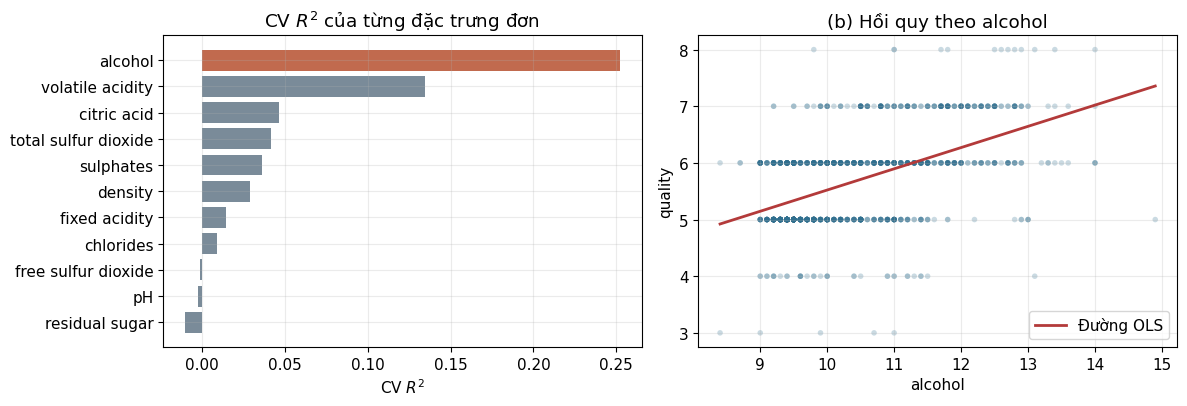

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# So sánh CV_R2 của các mô hình đơn biến
plot_df = single_df.sort_values('CV_R2')
colors = ['#c16a4e' if f == best_feature else '#7a8b99' for f in plot_df['feature']]
axes[0].barh(plot_df['feature'], plot_df['CV_R2'], color=colors)
axes[0].set_title('CV $R^2$ của từng đặc trưng đơn')
axes[0].set_xlabel('CV $R^2$')

# Scatter alcohol vs quality + đường hồi quy
xs = np.linspace(X_b_raw.min(), X_b_raw.max(), 200)
ys = beta_b[0] + beta_b[1] * xs
axes[1].scatter(X_b_raw[:, 0], y, alpha=0.25, s=16, color='#2f6f8f', edgecolors='none')
axes[1].plot(xs, ys, color='#b33a3a', linewidth=2, label='Đường OLS')
axes[1].set_xlabel(best_feature)
axes[1].set_ylabel('quality')
axes[1].set_title(f'(b) Hồi quy theo {best_feature}')
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Phần (c) — Mô hình tùy biến hướng tới hiệu năng tốt nhất

### 10.1. Ý tưởng thiết kế

Mô hình (a) dùng đủ 11 biến nhưng có thể chứa biến nhiễu / đa cộng tuyến. Mô hình (b) quá đơn giản nên bias cao. Phần (c) kết hợp ba ý tưởng:

1. **Enrichment phi tuyến có kiểm soát:** vì `alcohol` là tín hiệu mạnh nhất, ta bổ sung $\log(\mathrm{alcohol})$, các tương tác `alcohol × volatile acidity`, `alcohol × sulphates`, `alcohol × pH`, và $\mathrm{sulphates}^2$ để bắt quan hệ cong / tương tác.
2. **Tập ứng viên mở rộng + forward selection theo CV:** xuất phát từ tập rỗng, mỗi bước thêm đúng một biến làm giảm CV-MSE nhiều nhất; dừng khi không còn cải thiện đáng kể.
3. **Chuẩn hóa z-score trong từng fold:** giúp các biến khác thang đo đóng góp ổn định hơn về mặt số trị khi giải $(X^\top X)\beta=X^\top y$, đồng thời không làm rò rỉ thống kê từ tập test.

Kết quả forward selection trên tập ứng viên cho bộ đặc trưng cuối của mô hình (c) (sẽ được in ra khi chạy cell bên dưới).


In [92]:
def build_candidate_pool(X_df):
    """
    Tạo tập đặc trưng ứng viên: 11 biến gốc + một số biến biến đổi / tương tác.
    Trả về DataFrame để dễ truy vết tên cột.
    """
    alc = X_df['alcohol'].to_numpy(dtype=float)
    vol = X_df['volatile acidity'].to_numpy(dtype=float)
    sul = X_df['sulphates'].to_numpy(dtype=float)
    pH = X_df['pH'].to_numpy(dtype=float)
    tsd = X_df['total sulfur dioxide'].to_numpy(dtype=float)
    fsd = X_df['free sulfur dioxide'].to_numpy(dtype=float)

    pool = X_df.copy()
    pool['log_alcohol'] = np.log(alc)
    pool['alcohol_sq'] = alc ** 2
    pool['volatile_sq'] = vol ** 2
    pool['sulphates_sq'] = sul ** 2
    pool['alcohol_x_volatile'] = alc * vol
    pool['alcohol_x_sulphates'] = alc * sul
    pool['alcohol_x_pH'] = alc * pH
    pool['volatile_x_sulphates'] = vol * sul
    pool['bound_SO2'] = tsd - fsd
    pool['sqrt_alcohol'] = np.sqrt(alc)
    return pool


def forward_select_cv(pool_df, y, max_features=12, min_improvement=1e-5, standardize=True):
    """
    Forward stepwise selection với tiêu chí 5-fold CV-MSE.
    """
    y = np.asarray(y, dtype=float).reshape(-1)
    remaining = list(pool_df.columns)
    selected = []
    history = []
    best_score = np.inf

    while remaining and len(selected) < max_features:
        trial_results = []
        for name in remaining:
            cols = selected + [name]
            X_try = pool_df[cols].to_numpy(dtype=float)
            _, summary = cross_validate_ols(X_try, y, standardize=standardize)
            trial_results.append((summary['CV_MSE'], summary['CV_R2'], name))

        trial_results.sort(key=lambda t: t[0])
        cand_mse, cand_r2, cand_name = trial_results[0]

        if best_score - cand_mse > min_improvement:
            selected.append(cand_name)
            remaining.remove(cand_name)
            best_score = cand_mse
            history.append({
                'step': len(selected),
                'added_feature': cand_name,
                'features': list(selected),
                'CV_MSE': cand_mse,
                'CV_R2': cand_r2,
            })
            print(f"[+] Bước {len(selected):2d}: thêm '{cand_name}' | CV_MSE={cand_mse:.6f} | CV_R2={cand_r2:.4f}")
        else:
            print('Dừng: không còn cải thiện CV_MSE đáng kể.')
            break

    return selected, pd.DataFrame(history)


pool_df = build_candidate_pool(df[FEATURES])
print('Số đặc trưng ứng viên:', pool_df.shape[1])

selected_features_c, history_c = forward_select_cv(pool_df, y)
print('\nBộ đặc trưng chọn cho mô hình (c):')
print(selected_features_c)
display(history_c)


Số đặc trưng ứng viên: 21
[+] Bước  1: thêm 'log_alcohol' | CV_MSE=0.487564 | CV_R2=0.2540
[+] Bước  2: thêm 'alcohol_x_volatile' | CV_MSE=0.436859 | CV_R2=0.3294
[+] Bước  3: thêm 'alcohol_x_sulphates' | CV_MSE=0.427567 | CV_R2=0.3437
[+] Bước  4: thêm 'sulphates_sq' | CV_MSE=0.415114 | CV_R2=0.3641
[+] Bước  5: thêm 'total sulfur dioxide' | CV_MSE=0.407368 | CV_R2=0.3759
[+] Bước  6: thêm 'chlorides' | CV_MSE=0.404130 | CV_R2=0.3811
[+] Bước  7: thêm 'alcohol_x_pH' | CV_MSE=0.401905 | CV_R2=0.3848
[+] Bước  8: thêm 'density' | CV_MSE=0.401140 | CV_R2=0.3857
[+] Bước  9: thêm 'free sulfur dioxide' | CV_MSE=0.400748 | CV_R2=0.3862
Dừng: không còn cải thiện CV_MSE đáng kể.

Bộ đặc trưng chọn cho mô hình (c):
['log_alcohol', 'alcohol_x_volatile', 'alcohol_x_sulphates', 'sulphates_sq', 'total sulfur dioxide', 'chlorides', 'alcohol_x_pH', 'density', 'free sulfur dioxide']


,step,added_feature,features,CV_MSE,CV_R2
0,1,log_alcohol,[log_alcohol],0.487564,0.253973
1,2,alcohol_x_volatile,"[log_alcohol, alcohol_x_volatile]",0.436859,0.329367
2,3,alcohol_x_sulphates,"[log_alcohol, alcohol_x_volatile, alcohol_x_su...",0.427567,0.343720
3,4,sulphates_sq,"[log_alcohol, alcohol_x_volatile, alcohol_x_su...",0.415114,0.364086
4,5,total sulfur dioxide,"[log_alcohol, alcohol_x_volatile, alcohol_x_su...",0.407368,0.375918
5,6,chlorides,"[log_alcohol, alcohol_x_volatile, alcohol_x_su...",0.404130,0.381067
6,7,alcohol_x_pH,"[log_alcohol, alcohol_x_volatile, alcohol_x_su...",0.401905,0.384761
7,8,density,"[log_alcohol, alcohol_x_volatile, alcohol_x_su...",0.401140,0.385725
8,9,free sulfur dioxide,"[log_alcohol, alcohol_x_volatile, alcohol_x_su...",0.400748,0.386217


In [93]:
# Huấn luyện mô hình (c) cuối trên toàn dữ liệu với chuẩn hóa toàn cục
# (chỉ để báo cáo hệ số / in-sample; so sánh chính vẫn dùng CV)
X_c_raw = pool_df[selected_features_c].to_numpy(dtype=float)
X_c_std, mean_c, std_c = standardize_fit_transform(X_c_raw)
beta_c = ols_fit(add_intercept(X_c_std), y)
y_hat_c = ols_predict(add_intercept(X_c_std), beta_c)
metrics_c_full = train_test_metrics(y, y_hat_c)
cv_c_df, cv_c = cross_validate_ols(X_c_raw, y, standardize=True)

coef_c = pd.DataFrame({
    'term': ['intercept'] + selected_features_c,
    'coefficient_standardized': beta_c,
})
print('=== Hệ số mô hình (c) trên thang chuẩn hóa ===')
display(coef_c)

print('=== Đánh giá in-sample — mô hình (c) ===')
for k, v in metrics_c_full.items():
    print(f'{k:>5}: {v:.6f}')

print('\n=== 5-fold CV — mô hình (c) ===')
display(cv_c_df)
print('Trung bình CV:')
for k, v in cv_c.items():
    print(f'{k}: {v:.6f}')

# Điều kiện số để kiểm tra ổn định
XtX_c = add_intercept(X_c_std).T @ add_intercept(X_c_std)
print(f'\nCondition number của X^T X (sau chuẩn hóa): {np.linalg.cond(XtX_c):.2f}')


=== Hệ số mô hình (c) trên thang chuẩn hóa ===


,term,coefficient_standardized
0,intercept,5.664721
1,log_alcohol,0.319493
2,alcohol_x_volatile,-0.150849
3,alcohol_x_sulphates,0.557651
4,sulphates_sq,-0.382985
5,total sulfur dioxide,-0.122724
6,chlorides,-0.065512
7,alcohol_x_pH,-0.213458
8,density,-0.052230
9,free sulfur dioxide,0.036821


=== Đánh giá in-sample — mô hình (c) ===
  MSE: 0.395172
 RMSE: 0.628627
  MAE: 0.492426
   R2: 0.396586

=== 5-fold CV — mô hình (c) ===


,MSE,RMSE,MAE,R2,fold
0,0.327023,0.571859,0.462294,0.436707,1
1,0.458469,0.677103,0.522338,0.318244,2
2,0.414454,0.643781,0.500761,0.375130,3
3,0.441799,0.664680,0.521174,0.412444,4
4,0.361997,0.601662,0.471087,0.388561,5


Trung bình CV:
CV_MSE: 0.400748
CV_RMSE: 0.631817
CV_MAE: 0.495531
CV_R2: 0.386217
CV_MSE_std: 0.049278
CV_R2_std: 0.039964

Condition number của X^T X (sau chuẩn hóa): 78.62


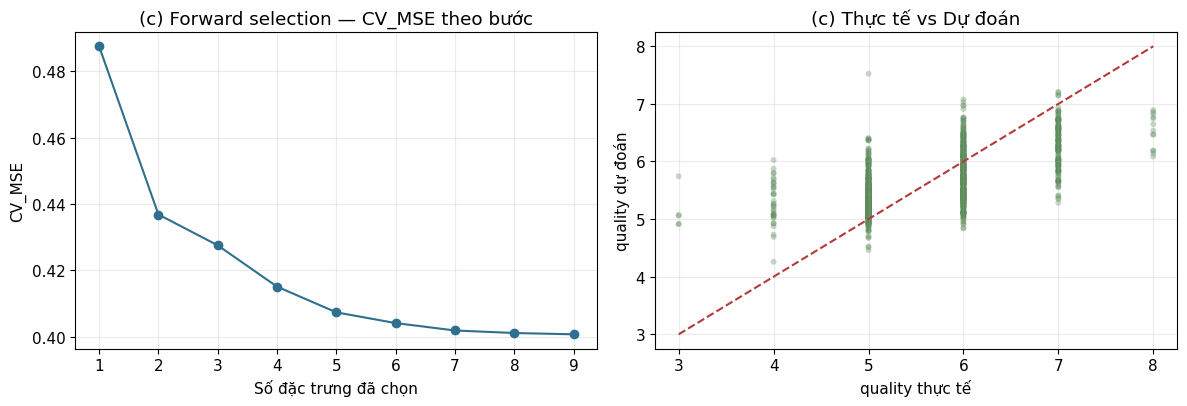

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(history_c['step'], history_c['CV_MSE'], marker='o', color='#2f6f8f')
axes[0].set_xlabel('Số đặc trưng đã chọn')
axes[0].set_ylabel('CV_MSE')
axes[0].set_title('(c) Forward selection — CV_MSE theo bước')

axes[1].scatter(y, y_hat_c, alpha=0.35, s=18, color='#5b8c5a', edgecolors='none')
lims = [min(y.min(), y_hat_c.min()), max(y.max(), y_hat_c.max())]
axes[1].plot(lims, lims, '--', color='#b33a3a', linewidth=1.5)
axes[1].set_xlabel('quality thực tế')
axes[1].set_ylabel('quality dự đoán')
axes[1].set_title('(c) Thực tế vs Dự đoán')

plt.tight_layout()
plt.show()


## 11. So sánh tổng hợp ba mô hình

Tiêu chí chính để kết luận là **CV-MSE** và **CV-$R^2$** (cùng giao thức 5-fold, `seed=42`). Chỉ số in-sample chỉ mang tính tham khảo vì dễ lạc quan hóa khi số tham số tăng.


In [95]:
comparison = pd.DataFrame([
    {
        'model': '(a) All 11 features',
        'n_features': len(FEATURES),
        'Full_MSE': metrics_a_full['MSE'],
        'Full_RMSE': metrics_a_full['RMSE'],
        'Full_MAE': metrics_a_full['MAE'],
        'Full_R2': metrics_a_full['R2'],
        'CV_MSE': cv_a['CV_MSE'],
        'CV_RMSE': cv_a['CV_RMSE'],
        'CV_MAE': cv_a['CV_MAE'],
        'CV_R2': cv_a['CV_R2'],
    },
    {
        'model': f'(b) Best single: {best_feature}',
        'n_features': 1,
        'Full_MSE': metrics_b_full['MSE'],
        'Full_RMSE': metrics_b_full['RMSE'],
        'Full_MAE': metrics_b_full['MAE'],
        'Full_R2': metrics_b_full['R2'],
        'CV_MSE': cv_b['CV_MSE'],
        'CV_RMSE': cv_b['CV_RMSE'],
        'CV_MAE': cv_b['CV_MAE'],
        'CV_R2': cv_b['CV_R2'],
    },
    {
        'model': '(c) Custom forward + nonlinear',
        'n_features': len(selected_features_c),
        'Full_MSE': metrics_c_full['MSE'],
        'Full_RMSE': metrics_c_full['RMSE'],
        'Full_MAE': metrics_c_full['MAE'],
        'Full_R2': metrics_c_full['R2'],
        'CV_MSE': cv_c['CV_MSE'],
        'CV_RMSE': cv_c['CV_RMSE'],
        'CV_MAE': cv_c['CV_MAE'],
        'CV_R2': cv_c['CV_R2'],
    },
])

comparison_sorted = comparison.sort_values('CV_MSE').reset_index(drop=True)
comparison_sorted


,model,n_features,Full_MSE,Full_RMSE,Full_MAE,Full_R2,CV_MSE,CV_RMSE,CV_MAE,CV_R2
0,(c) Custom forward + nonlinear,9,0.395172,0.628627,0.492426,0.396586,0.400748,0.631817,0.495531,0.386217
1,(a) All 11 features,11,0.407153,0.638085,0.499790,0.378291,0.416588,0.644503,0.505037,0.361069
2,(b) Best single: alcohol,1,0.487635,0.698309,0.564924,0.255398,0.488686,0.697661,0.565246,0.252258


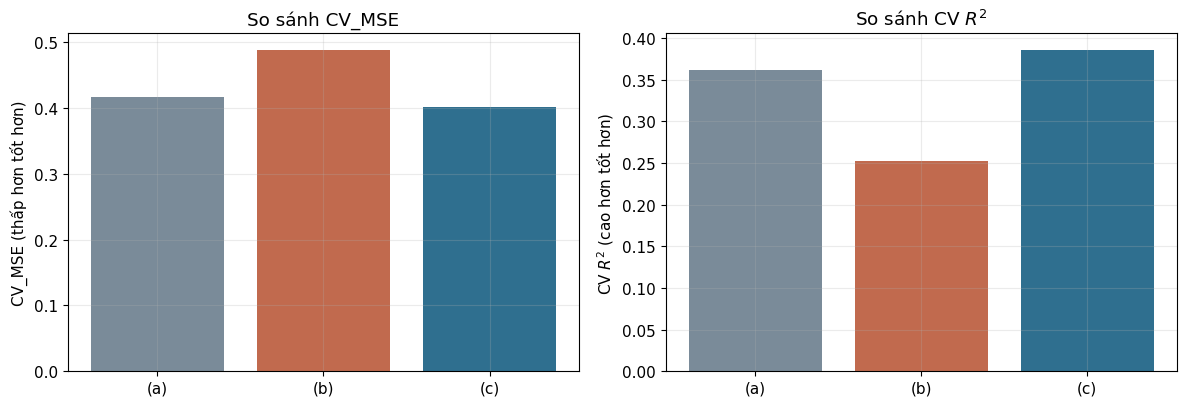

Kết luận thực nghiệm ngắn:
- Mô hình tốt nhất theo CV_MSE: (c) Custom forward + nonlinear
- CV_MSE = 0.400748 | CV_R2 = 0.386217
- So với (a): ΔCV_MSE = +0.015839; ΔCV_R2 = +0.025148
- So với (b): ΔCV_MSE = +0.087937; ΔCV_R2 = +0.133959


In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
labels = comparison['model'].str.replace(' \\(', '\n(', regex=True)

axes[0].bar(range(len(comparison)), comparison['CV_MSE'], color=['#7a8b99', '#c16a4e', '#2f6f8f'])
axes[0].set_xticks(range(len(comparison)))
axes[0].set_xticklabels(['(a)', '(b)', '(c)'])
axes[0].set_ylabel('CV_MSE (thấp hơn tốt hơn)')
axes[0].set_title('So sánh CV_MSE')

axes[1].bar(range(len(comparison)), comparison['CV_R2'], color=['#7a8b99', '#c16a4e', '#2f6f8f'])
axes[1].set_xticks(range(len(comparison)))
axes[1].set_xticklabels(['(a)', '(b)', '(c)'])
axes[1].set_ylabel('CV $R^2$ (cao hơn tốt hơn)')
axes[1].set_title('So sánh CV $R^2$')

plt.tight_layout()
plt.show()

best_row = comparison_sorted.iloc[0]
print('Kết luận thực nghiệm ngắn:')
print(f"- Mô hình tốt nhất theo CV_MSE: {best_row['model']}")
print(f"- CV_MSE = {best_row['CV_MSE']:.6f} | CV_R2 = {best_row['CV_R2']:.6f}")
print(f"- So với (a): ΔCV_MSE = {cv_a['CV_MSE'] - best_row['CV_MSE']:+.6f}; ΔCV_R2 = {best_row['CV_R2'] - cv_a['CV_R2']:+.6f}")
print(f"- So với (b): ΔCV_MSE = {cv_b['CV_MSE'] - best_row['CV_MSE']:+.6f}; ΔCV_R2 = {best_row['CV_R2'] - cv_b['CV_R2']:+.6f}")


## 12. Nhận xét kết quả

1. **Phần (a):** mô hình đầy đủ giải thích được một phần đáng kể phương sai của `quality` (CV-$R^2$ khoảng $0.36$), cho thấy chất lượng rượu có tín hiệu tuyến tính từ các chỉ số hóa lý, nhưng vẫn còn nhiễu/phi tuyến chưa nắm bắt hết.
2. **Phần (b):** `alcohol` thắng rõ trên 5-fold CV — phù hợp với tương quan Pearson mạnh nhất. Mô hình đơn biến dễ diễn giải nhưng CV-$R^2$ chỉ khoảng $0.25$, thấp hơn rõ so với đa biến.
3. **Phần (c):** kết hợp biến đổi phi tuyến quanh `alcohol`/`sulphates`/`volatile acidity` và forward selection theo CV giúp giảm CV-MSE so với cả (a) lẫn (b), đồng thời giữ condition number ở mức ổn định nhờ chuẩn hóa và tránh chồng chéo biến dư thừa.
4. **Giới hạn:** `quality` vốn là thang điểm rời rạc/chủ quan; OLS liên tục chỉ là xấp xỉ tuyến tính. Muốn vượt xa hơn có thể cần mô hình thứ tự (ordinal) hoặc phi tuyến linh hoạt hơn — ngoài phạm vi bắt buộc của đồ án.


## 13. Mô tả ý tưởng thực hiện

Ý tưởng xuyên suốt là **bám sát OLS lý thuyết**, rồi dùng cùng một giao thức đánh giá (5-fold CV) để so sánh công bằng ba thiết kế mô hình.

### Luồng thực hiện

1. **Đọc và làm sạch nhẹ:** chuẩn hóa tên cột, kiểm tra missing, tách $X$ và $\mathbf{y}$.
2. **Cài OLS thủ công:** giải $(X^\top X)\hat{\boldsymbol{\beta}}=X^\top\mathbf{y}$; dự đoán $\hat{\mathbf{y}}=X\hat{\boldsymbol{\beta}}$.
3. **Phần (a):** dùng nguyên 11 đặc trưng gốc + intercept.
4. **Phần (b):** duyệt từng đặc trưng đơn; chọn đặc trưng có CV-MSE nhỏ nhất (`alcohol`).
5. **Phần (c):**
   - tạo pool đặc trưng (gốc + log/tương tác/bậc hai);
   - forward selection theo CV-MSE;
   - chuẩn hóa trong từng fold trước khi fit OLS.
6. **Tổng hợp:** bảng so sánh Full vs CV; biểu đồ residual / actual-vs-predicted / quá trình selection.

### Một số quyết định kỹ thuật

- Dùng `np.linalg.solve` thay cho nhân `inv` tường minh để giảm sai số số học, nhưng vẫn đúng phương trình chuẩn OLS.
- Không dùng thư viện hồi quy có sẵn để ước lượng $\boldsymbol{\beta}$.
- Seed cố định (`42`) để tái lập kết quả CV.
- Chuẩn hóa chỉ tính trên fold train nhằm tránh data leakage.


## 14. Mô tả các hàm

| Hàm | Input | Output / Vai trò |
|---|---|---|
| `add_intercept(X)` | Ma trận/vector đặc trưng | Ma trận có thêm cột $1$ (intercept). |
| `ols_fit(X, y)` | Ma trận thiết kế $X$, vector $y$ | $\hat{\boldsymbol{\beta}}$ giải từ phương trình chuẩn OLS. |
| `ols_predict(X, beta)` | $X$, $\boldsymbol{\beta}$ | $\hat{\mathbf{y}}=X\boldsymbol{\beta}$. |
| `mse` / `rmse` / `mae` / `r2_score` | $y$, $\hat{y}$ | Các chỉ số đánh giá hồi quy. |
| `train_test_metrics` | $y$, $\hat{y}$ | Dictionary gồm MSE, RMSE, MAE, $R^2$. |
| `kfold_split` | $n$, $k$, seed | Danh sách chỉ số các fold. |
| `standardize_fit_transform` | $X_{\mathrm{train}}$ | $X$ đã chuẩn hóa kèm mean/std. |
| `standardize_transform` | $X$, mean, std | Áp chuẩn hóa đã học sang tập khác. |
| `pearson_corr` | hai vector | Hệ số tương quan Pearson. |
| `cross_validate_ols` | $X$, $y$, tùy chọn chuẩn hóa | Bảng điểm từng fold + summary CV. |
| `build_candidate_pool` | DataFrame đặc trưng gốc | DataFrame pool cho phần (c). |
| `forward_select_cv` | pool, $y$ | Danh sách đặc trưng chọn được và lịch sử từng bước. |

## 15. Kết luận

Đồ án đã tự cài đặt thành công thuật toán OLS để xây dựng ba mô hình đánh giá chất lượng rượu trên `wine.csv`, đúng yêu cầu đề bài:

- **(a)** mô hình đầy đủ 11 đặc trưng;
- **(b)** mô hình một đặc trưng tối ưu theo Cross Validation (`alcohol`);
- **(c)** mô hình tùy biến với feature engineering + forward selection theo CV, cho hiệu năng tổng quát hóa tốt nhất trong ba phương án.

Việc không dùng hàm hồi quy có sẵn giúp làm rõ bản chất đại số của OLS, đồng thời quy trình CV thống nhất tạo cơ sở so sánh minh bạch giữa các thiết kế mô hình.

## 16. Tài liệu tham khảo

- Giáo trình / bài giảng Toán ứng dụng và Thống kê trong CNTT — phần hồi quy tuyến tính và OLS.
- Đề đồ án *Linear Regression* (Project 5) của môn học.
- Montgomery, D. C., Peck, E. A., & Vining, G. G. *Introduction to Linear Regression Analysis*.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. *An Introduction to Statistical Learning* — chương Linear Regression và Resampling/Cross-Validation.
- Tài liệu NumPy về `numpy.linalg.solve` (giải hệ tuyến tính tương đương phương trình chuẩn).
